# 最簡Teachable Machine動物辨識模型程式

這個筆記本提供了一個精簡版的動物辨識模型程式，讓您可以快速上手。它使用了預訓練的 MobileNetV2 模型進行轉移學習，並讓您能夠使用自己的圖片來訓練和測試模型。

In [13]:
# 載入必要的函式庫
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import os
import requests
from PIL import Image, ImageOps
from io import BytesIO

print("函式庫載入完成！")

函式庫載入完成！


In [ ]:
# 修正 Matplotlib 中文顯示問題
!pip install -q matplotlib==3.7.1 # 確保 Matplotlib 版本
!pip install -q taiwan-atlas

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 下載並安裝 Noto Sans CJK TC 字體
!wget -q -O '/usr/share/fonts/truetype/NotoSansCJKtc-Regular.otf' https://github.com/googlefonts/noto-cjk/raw/main/Sans/NotoSansCJKtc-Regular.otf

# 重新建立 Matplotlib 字體快取
fm.fontManager.addfont('/usr/share/fonts/truetype/NotoSansCJKtc-Regular.otf')
mpl.font_manager._rebuild()

# 設定 Matplotlib 使用 Noto Sans CJK TC 字體
mpl.rc('font', family='Noto Sans CJK TC')
mpl.rc('axes', unicode_minus=False) # 解決負號亂碼問題

print("Matplotlib 中文顯示設定完成！請重新執行包含圖表的儲存格。")

### 1. 資料準備 (最關鍵步驟！)

**您必須手動將您的動物圖片上傳到 Colab 環境中，並依循以下資料夾結構。**

**步驟：**
1.  **在 Colab 左側的檔案瀏覽器中**：右鍵點擊左側文件瀏覽器的空白區域，選擇「新增資料夾」。
2.  **建立 `dataset` 資料夾**：在根目錄 `/content/` 下建立一個名為 `dataset` 的資料夾。
3.  **建立 `train` 和 `validation` 資料夾**：在 `dataset` 內，分別建立 `train` 和 `validation` 這兩個資料夾。
4.  **為每個類別建立子資料夾**：
    *   在 `train` 和 `validation` 資料夾內，為您的每個動物類別建立一個子資料夾 (例如：`cat`, `dog`, `bird` 等)。這些資料夾的名稱將成為您的模型類別名稱。
    *   **重要提示**：`train` 和 `validation` 中的類別子資料夾名稱必須保持一致。
5.  **上傳您的圖片**：
    *   將用於訓練的圖片上傳到 `dataset/train/` 下對應的類別子資料夾中。
    *   將用於驗證模型的小部分圖片上傳到 `dataset/validation/` 下對應的類別子資料夾中。

**範例資料夾結構 (請務必遵照此格式)：**
```
/content/
└── dataset/
    ├── train/                    # 訓練資料集
    │   ├── cat/                  # 貓的圖片
    │   │   ├── cat_image_1.jpg
    │   │   └── cat_image_2.jpg
    │   └── dog/                  # 狗的圖片
    │       ├── dog_image_1.jpg
    │       └── dog_image_2.jpg
    └── validation/               # 驗證資料集 (用於評估模型，通常圖片數量較少)
        ├── cat/
        │   └── cat_image_test.jpg
        └── dog/
            └── dog_image_test.jpg
```

**完成以上手動步驟後，再執行下一個程式碼儲存格。**

In [32]:
import os

# 定義資料夾結構
base_dir = '/content/dataset'
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')

# 我們將預設建立 'cat' 和 'dog' 類別的資料夾
# 如果您有其他類別，請在手動上傳圖片後再修改或新增
class_names = ['cat', 'dog']

# 確保資料夾存在
for dir_path in [train_dir, validation_dir]:
    for class_name in class_names:
        os.makedirs(os.path.join(dir_path, class_name), exist_ok=True)

print("空的資料夾結構已建立。\n請依照上方文字儲存格的說明，手動上傳您的貓和狗圖片到：")
print(f"  - {train_dir}/cat/")
print(f"  - {train_dir}/dog/")
print(f"  - {validation_dir}/cat/")
print(f"  - {validation_dir}/dog/")
print("手動上傳完成後，即可執行下一個儲存格來載入資料集。")
# 移除圖片下載邏輯，因為公共圖片連結不可靠且易受訪問限制

空的資料夾結構已建立。
請依照上方文字儲存格的說明，手動上傳您的貓和狗圖片到：
  - /content/dataset/train/cat/
  - /content/dataset/train/dog/
  - /content/dataset/validation/cat/
  - /content/dataset/validation/dog/
手動上傳完成後，即可執行下一個儲存格來載入資料集。


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [21]:
# 設定圖片尺寸和批次大小
img_height = 224
img_width = 224
batch_size = 32

# 從資料夾載入訓練資料集
train_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset/train',
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True
)

# 從資料夾載入驗證資料集
val_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset/validation',
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False
)

# 獲取類別名稱
class_names = train_ds.class_names
num_classes = len(class_names)
print(f"偵測到的類別: {class_names}")
print(f"總類別數量: {num_classes}")

# 設定資料集以提高性能
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


Found 4 files belonging to 2 classes.
Found 2 files belonging to 2 classes.
偵測到的類別: ['cat', 'dog']
總類別數量: 2


### 2. 建立與訓練模型 (使用轉移學習)

我們將使用預訓練的 MobileNetV2 模型作為基礎，並在其頂部添加一個新的分類層。


In [22]:
# 定義資料增強層，幫助模型泛化
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal", input_shape=(img_height, img_width, 3)),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ]
)

# 載入預訓練的 MobileNetV2 模型，不包含頂部分類層
base_model = keras.applications.MobileNetV2(input_shape=(img_height, img_width, 3),
                                               include_top=False,
                                               weights='imagenet')

# 凍結基礎模型層，使其在訓練期間不會被更新 (轉移學習的關鍵)
base_model.trainable = False

# 建立新的分類模型
inputs = keras.Input(shape=(img_height, img_width, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x) # MobileNetV2 特定的預處理
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x) # 全局平均池化，將特徵圖轉換為單一向量
x = layers.Dropout(0.2)(x) # 加入 Dropout 層防止過擬合
outputs = layers.Dense(num_classes, activation='softmax')(x) # 輸出層，根據類別數量決定
model = keras.Model(inputs, outputs)

model.summary()

# 編譯模型
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss=keras.losses.SparseCategoricalCrossentropy(), # 適用於整數標籤
              metrics=['accuracy'])

# 設定訓練的 epoch 數
epochs = 10 # 您可以根據資料量和硬體性能調整此值

print(f"開始訓練模型，共 {epochs} 個週期...")
# 訓練模型
history = model.fit(train_ds,
                    epochs=epochs,
                    validation_data=val_ds)
print("模型訓練完成！")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_2 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_2 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

開始訓練模型，共 10 個週期...
Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.2500 - loss: 1.0051 - val_accuracy: 1.0000 - val_loss: 0.3209
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.7500 - loss: 0.5922 - val_accuracy: 1.0000 - val_loss: 0.2548
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.7500 - loss: 0.4614 - val_accuracy: 1.0000 - val_loss: 0.2020
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.7500 - loss: 0.2921 - val_accuracy: 1.0000 - val_loss: 0.1521
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.7500 - loss: 0.3931 - val_accuracy: 1.0000 - val_loss: 0.1107
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 1.0000 - loss: 0.1453 - val_accuracy: 1.0000 - val_loss: 0.0820
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 1.0000 - loss: 0.2796 - val_accuracy: 1.0000 - val_loss: 0.0606
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 1.0000 - loss: 0.1361 - val_accuracy: 1.

### 3. 評估訓練結果

此圖表顯示了訓練過程中模型在訓練集和驗證集上的準確度和損失變化，幫助您判斷模型是否訓練良好或存在過擬合。

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 35347 (\N{CJK UNIFIED IDEOGRAPH-8A13}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32244 (\N{CJK UNIFIED IDEOGRAPH-7DF4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 33287 (\N{CJK UNIFIED IDEOGRAPH-8207}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 39511 (\N{CJK UNIFIED IDEOGRAPH-9A57}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 35657 (\N{CJK UNIFIED IDEOGRAPH-8B49}) missing from font(s) DejaVu Sans.
  fig.canvas

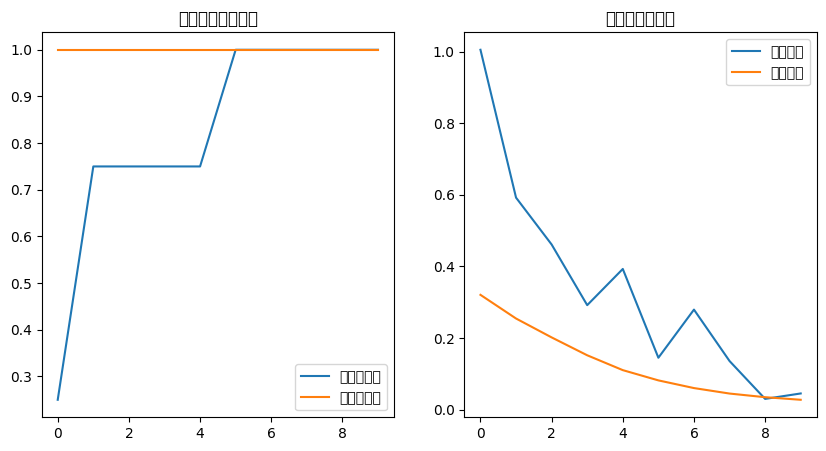

In [23]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='訓練準確度')
plt.plot(epochs_range, val_acc, label='驗證準確度')
plt.legend(loc='lower right')
plt.title('訓練與驗證準確度')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='訓練損失')
plt.plot(epochs_range, val_loss, label='驗證損失')
plt.legend(loc='upper right')
plt.title('訓練與驗證損失')
plt.show()


### 4. 進行預測

現在，我們可以使用訓練好的模型來對新的圖片進行辨識。

請提供一張您已上傳的圖片路徑進行預測...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
這張圖片很可能是 dog，置信度為 71.85%


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 38928 (\N{CJK UNIFIED IDEOGRAPH-9810}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 28204 (\N{CJK UNIFIED IDEOGRAPH-6E2C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


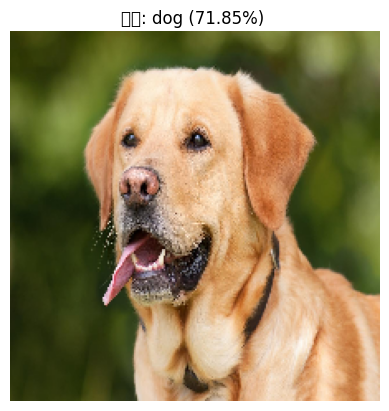

In [33]:
def predict_single_image(image_path):
    try:
        img = tf.keras.utils.load_img(
            image_path, target_size=(img_height, img_width)
        )
        img_array = tf.keras.utils.img_to_array(img)
        img_array = tf.expand_dims(img_array, 0) # 為模型增加一個批次維度

        predictions = model.predict(img_array)
        score = tf.nn.softmax(predictions[0])

        predicted_class_index = np.argmax(score)
        predicted_class_name = class_names[predicted_class_index]
        confidence = 100 * np.max(score)

        print(f"這張圖片很可能是 {predicted_class_name}，置信度為 {confidence:.2f}%")
        plt.imshow(img)
        plt.title(f"預測: {predicted_class_name} ({confidence:.2f}%) ")
        plt.axis('off')
        plt.show()
    except Exception as e:
        print(f"無法載入或處理圖片 {image_path}: {e}")


# --- 範例預測：使用您上傳的圖片 --- #
print("請提供一張您已上傳的圖片路徑進行預測...")
# 範例：假設您已將一張狗的圖片上傳到 /content/dataset/validation/dog/dog_example.jpg
# 請將以下的路徑替換為您實際的圖片路徑。
# 如果您尚未上傳圖片，可以暫時跳過此儲存格，或先上傳一張圖片再試。

your_uploaded_image_path = '/content/dataset/validation/dog/dog_val.jpg' # 將範例路徑改為您已上傳的圖片路徑

if os.path.exists(your_uploaded_image_path):
    predict_single_image(your_uploaded_image_path)
else:
    print(f"錯誤：找不到圖片 {your_uploaded_image_path}")
    print("請確保您已經依照步驟將圖片上傳到正確的路徑，或修改 `your_uploaded_image_path` 變數。")

# 移除網路圖片下載邏輯，因為公共圖片連結不可靠且易受訪問限制